# AI Multi-Disease Diagnostic Assistant — Exploration

This notebook narrates the data, modelling, and results behind the project. It reuses the
same `src/` modules that power training and the Streamlit app, so nothing here diverges
from production code.

**Five prediction tasks:** a symptom-based multi-disease checker plus dedicated models for
diabetes, heart disease, cardiovascular disease, and stroke. For each we compare classical
ML (Logistic Regression, Random Forest, XGBoost) against a TensorFlow neural network.

> Educational project on public datasets — not a medical device.

In [1]:
import sys
from pathlib import Path

# Make the project importable when running from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import DATASETS
from src.datasets import load_dataset
from src import artifacts

pd.set_option("display.max_columns", 50)
list(DATASETS.items())

[('symptoms', 'Multi-Disease Symptom Checker'),
 ('diabetes', 'Diabetes Risk'),
 ('heart', 'Heart Disease'),
 ('cardio', 'Cardiovascular Disease'),
 ('stroke', 'Stroke Risk')]

## 1. A look at each dataset

Every loader returns a standardised `PreparedData` bundle (cleaned features `X`, encoded
target `y`, column roles, and app metadata). Below we summarise class balance and shape.

In [2]:
summary = []
for slug in DATASETS:
    d = load_dataset(slug)
    pos_rate = None
    if d.task == "binary":
        pos_rate = float((d.y == 1).mean())
    summary.append({
        "dataset": d.label,
        "task": d.task,
        "samples": len(d.X),
        "classes": len(d.target_names),
        "numeric": len(d.numeric_cols),
        "categorical": len(d.categorical_cols),
        "positive_rate": round(pos_rate, 3) if pos_rate is not None else "-",
    })
pd.DataFrame(summary)

,dataset,task,samples,classes,numeric,categorical,positive_rate
0,Multi-Disease Symptom Checker,multiclass,4920,41,131,0,-
1,Diabetes Risk,binary,768,2,8,0,0.349
2,Heart Disease,binary,920,2,6,7,0.553
3,Cardiovascular Disease,binary,68613,2,5,6,0.495
4,Stroke Risk,binary,5110,2,3,7,0.049


## 2. Model comparison across all tasks

The training pipeline (`python -m src.train`) writes a `metrics.json` per dataset. We load
them and line the models up side by side. The winning model is chosen by ROC-AUC for binary
tasks and macro-F1 for the multiclass symptom checker.

In [3]:
rows = []
for slug in DATASETS:
    if not artifacts.is_trained(slug):
        continue
    meta = artifacts.load_metadata(slug)
    for model, m in artifacts.load_metrics(slug).items():
        rows.append({
            "dataset": meta["label"],
            "model": model,
            "accuracy": m.get("accuracy"),
            "f1_macro": m.get("f1_macro"),
            "roc_auc": m.get("roc_auc"),
            "top3": m.get("top3_accuracy"),
            "train_s": m.get("train_time_s"),
            "best": "*" if model == meta["best_model"] else "",
        })

comparison = pd.DataFrame(rows)
comparison

,dataset,model,accuracy,f1_macro,roc_auc,top3,train_s,best
0,Multi-Disease Symptom Checker,logistic_regression,1.000000,1.000000,NaN,1.0,0.06,*
1,Multi-Disease Symptom Checker,random_forest,1.000000,1.000000,NaN,1.0,0.45,
2,Multi-Disease Symptom Checker,xgboost,1.000000,1.000000,NaN,1.0,3.61,
3,Multi-Disease Symptom Checker,neural_network,1.000000,1.000000,NaN,1.0,12.42,
4,Diabetes Risk,logistic_regression,0.733766,0.717456,0.812593,NaN,0.00,
5,Diabetes Risk,random_forest,0.746753,0.729399,0.830556,NaN,0.32,*
6,Diabetes Risk,xgboost,0.740260,0.714815,0.813333,NaN,0.11,
7,Diabetes Risk,neural_network,0.720779,0.703674,0.816481,NaN,3.55,
8,Heart Disease,logistic_regression,0.831522,0.828847,0.904113,NaN,0.00,
9,Heart Disease,random_forest,0.853261,0.851324,0.921868,NaN,0.33,*


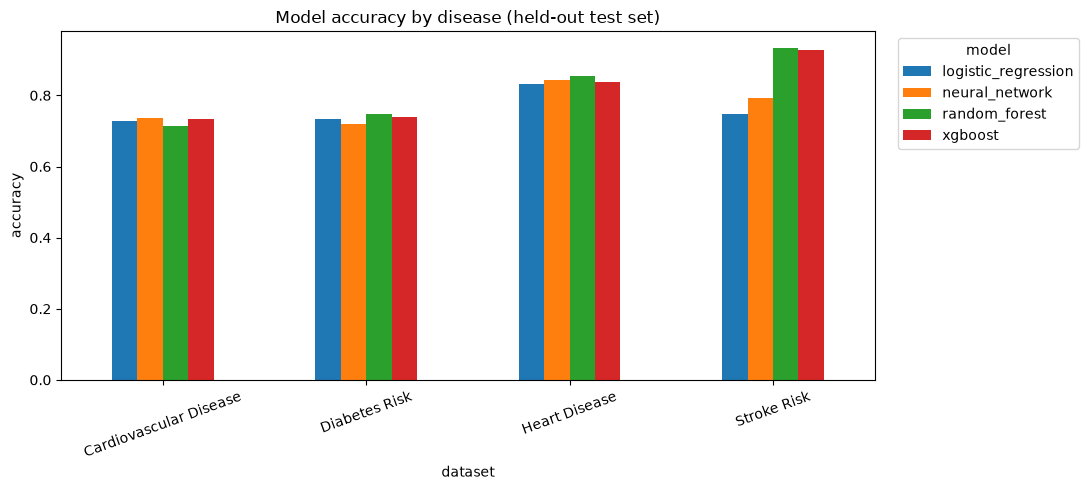

In [4]:
# Accuracy by model for the four binary tasks (symptom checker excluded: trivially ~1.0).
binary = comparison[comparison["dataset"] != DATASETS["symptoms"]]
pivot = binary.pivot_table(index="dataset", columns="model", values="accuracy")
ax = pivot.plot(kind="bar", figsize=(11, 5), rot=20)
ax.set_ylabel("accuracy")
ax.set_title("Model accuracy by disease (held-out test set)")
ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. What drives predictions

Global feature importance for each best model (SHAP / tree importances for tree models,
coefficients for linear, permutation for the neural net). This is the interpretability
layer that also appears live in the app.

In [5]:
from src.explain import compute_global_importance

for slug in ["heart", "cardio", "diabetes", "stroke"]:
    if artifacts.is_trained(slug):
        print(f"\n=== {DATASETS[slug]} (best: {artifacts.load_metadata(slug)['best_model']}) ===")
        display(compute_global_importance(slug, top_n=8))


=== Heart Disease (best: random_forest) ===


,raw_feature,importance
0,chol,0.135575
1,age,0.110135
2,thalch,0.107961
3,oldpeak,0.097583
4,cp=asymptomatic,0.096189
5,trestbps,0.069874
6,exang=True,0.063496
7,exang=False,0.044820



=== Cardiovascular Disease (best: neural_network) ===


,raw_feature,importance
0,ap_hi,0.186
1,age_years,0.052
2,ap_lo,0.028
3,cholesterol=Well above normal,0.014
4,weight,0.014
5,gender=Men,0.012
6,active=No,0.010
7,smoke=Yes,0.010



=== Diabetes Risk (best: random_forest) ===


,raw_feature,importance
0,Glucose,0.259895
1,BMI,0.165608
2,Age,0.125240
3,DiabetesPedigreeFunction,0.121162
4,Insulin,0.100081
5,BloodPressure,0.080995
6,SkinThickness,0.074034
7,Pregnancies,0.072984



=== Stroke Risk (best: logistic_regression) ===


,raw_feature,importance
0,age,1.879506
1,work_type=children,0.717638
2,work_type=Self-employed,0.430494
3,hypertension=No,0.377723
4,smoking_status=never smoked,0.286884
5,hypertension=Yes,0.217694
6,work_type=Govt_job,0.213088
7,smoking_status=smokes,0.210008


## 4. Takeaways & limitations

- **Neural nets aren't always the answer.** On the small clinical tables (diabetes, heart)
  Random Forest matches or beats the TensorFlow MLP; the neural net only pulls ahead on the
  large ~70k-row cardiovascular dataset, where it has enough data to shine.
- **The symptom checker scores ~100%** because the dataset is small and each disease maps to
  an almost unique symptom set — a clean pattern-recognition demo, not real diagnostic skill.
- **Stroke is heavily imbalanced (~5% positive).** Accuracy is misleading there; we rely on
  ROC-AUC and balanced class weights, and macro-F1 stays modest — an honest reflection of the
  difficulty.
- **Not a medical device.** All datasets are public and simplified; real diagnosis needs
  richer data, clinical validation, and regulatory rigour.